In [ ]:
!pip install spatialdata spatialdata_plot scanpy squidpy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import

In [ ]:
##Working with google colab
import torch
import os
import sys

os.chdir("/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples")
cwd = os.getcwd()
print(cwd)

sys.path.append("../")
if torch.cuda.is_available():
    device = "cuda"
    print("GPU: ",torch.cuda.get_device_name(0))
else:
    device = "cpu"
    print("Using CPU")

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples
Using CPU


In [ ]:
import scanpy as sc
import squidpy as sq
import spatialdata as sd
import spatialdata_plot
import pandas as pd
from tqdm.notebook import tqdm
import scipy as sp
import numpy as np
import multiprocessing
import pickle as pkl
import torch
from torch import nn
import gc
import sklearn.metrics

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

/usr/local/lib/python3.12/dist-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


In [ ]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['font.family'] = 'DejaVu Sans'

pltkw = dict(bbox_inches='tight', transparent=True)

In [ ]:
import steamboat as sf
import steamboat.tools
# importlib.reload(spaceformer.benchmarks)

## Head weights

In [ ]:
s_path = "/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/ann_data.zarr"
sdata = sd.read_zarr(s_path)

In [ ]:
adata = sc.read_h5ad("/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/ann_data.h5ad")

In [ ]:
adatas = []
for i in adata.obs['region'].unique():
    adatas.append(adata[adata.obs['region'] == i])
    adatas[-1].obs['global'] = 0  #Only support one unique value for regional observation.

/tmp/ipython-input-4759537.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adatas[-1].obs['global'] = 0  #Only support one unique value for regional observation.


In [ ]:
adatas = sf.prep_adatas(adatas, norm=True, log1p=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
model = sf.Steamboat(adatas[0].var_names.tolist(), n_heads=50, n_scales=3)
model = model.to(device)
model.load_state_dict(torch.load('saved_models/Breast_Cancer_50_0.1.pth', map_location=torch.device(device),weights_only=True), strict=False)


<All keys matched successfully>

Using None to mask variables. Explicitly specify `mask_var=False` to use all genes.
Using ['global'] as regional annotations.


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:02<00:00,  2.59s/it]


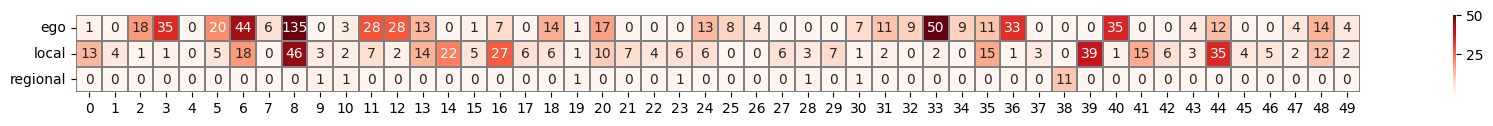

In [ ]:
dataset = sf.make_dataset(adatas, regional_obs=['global'])
sf.tools.calc_obs(adatas, dataset, model)
head_weights = sf.tools.calc_head_weights(device, adatas, model)
sf.tools.plot_head_weights(head_weights, figsize=(24, 1), multiplier=1000, heatmap_kwargs={'vmax': 50})

In [ ]:
for key in adatas[0].obsm.keys():
  print(key)

spatial
X_recon
q
local_k
global_k_0
attn
ego_attn
local_attn
global_attn_0


In [ ]:
criterion = nn.MSELoss(reduction='mean')
loss = criterion(torch.Tensor(adatas[0].obsm['X_recon']), torch.Tensor(adatas[0].X.toarray()))
loss

tensor(0.0875)

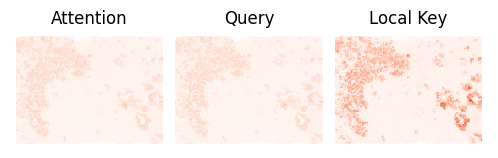

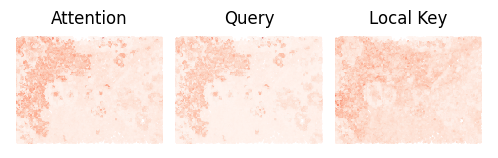

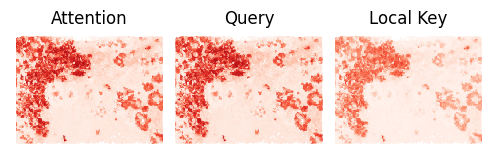

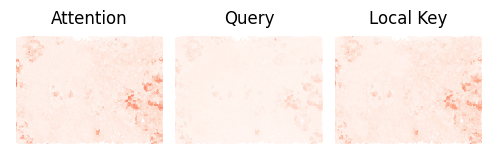

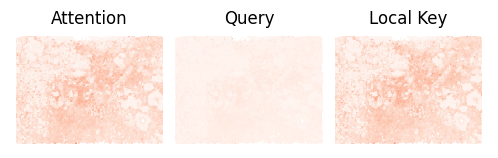

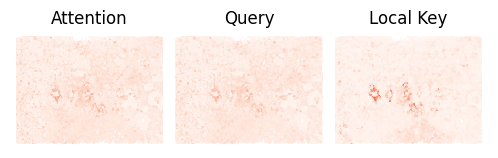

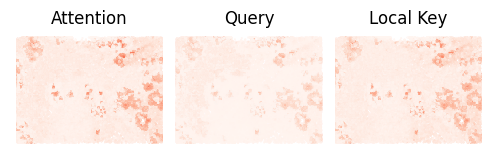

In [ ]:
l = [3, 6, 8, 16, 39, 40, 44]
for i_head in l: ## Change this to see more
    adatas[0].obs['a_obs'] = adatas[0].obsm['attn'][:, i_head]
    adatas[0].obs['q_obs'] = adatas[0].obsm['ego_attn'][:, i_head]
    adatas[0].obs['k_obs'] = adatas[0].obsm['local_attn'][:, i_head]

    sq.pl.spatial_scatter(adatas[0],
                          color=['a_obs', 'q_obs', 'k_obs'],
                          shape=None, figsize=(2, 2), size=0.25,
                          legend_fontsize=9, cmap='Reds', ncols=3,
                          colorbar=False, vmin=0., wspace=.0,
                          outline=False, frameon=False,
                          title=['Attention', 'Query', 'Local Key']
                          )

## Clustering and spatial domain segmentaiton

In [ ]:
cell_anno_path = "/content/drive/MyDrive/Thesis/Projects/Data/Breast_Cancer/Cell_Barcode_Type_Matrices.xlsx"

df = pd.read_excel(cell_anno_path,
                   sheet_name="Xenium R1 Fig1-5 (supervised)"
                   )

sdata['table'].obs["cell_type"] = (
    sdata['table'].obs["cell_id"]
    .map(df.set_index("Barcode")["Cluster"])
)

In [ ]:
adatas[0].obsm.keys()

KeysView(AxisArrays with keys: spatial, X_recon, q, local_k, global_k_0, attn, ego_attn, local_attn, global_attn_0)

In [ ]:
!pip install igraph leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 101.3 MB/s eta 0:00:00


In [ ]:
sf.tools.neighbors(adatas[0], 'attn')  #compute a neighborhood graph on attention embeddings
sf.tools.leiden(adatas[0], resolution=1.)  #clustering cells using the Leiden algorithm

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples/../steamboat/tools.py:410: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(adata, obsp=obsp, key_added=key_added, resolution=resolution, **leiden_kwargs)


In [ ]:
axes = plt.subplots(1, 2, figsize=(20, 12))[1].flatten()

sq.pl.spatial_scatter(
    adatas[0], color=['cell_type'], title=['Annotated Cell Types'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adatas[0], color=['steamboat_clusters'], title=['sc#3 clusters by attention scores'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

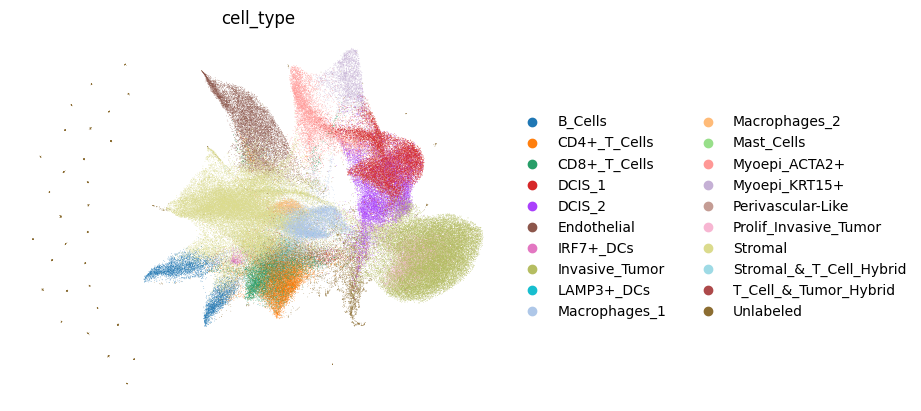

In [ ]:
ad = adata
ad.obsm["attn"] = adatas[0].obsm["attn"]

# Build neighbors using attention space
sc.pp.neighbors(ad, use_rep="attn")

# Compute UMAP
sc.tl.umap(ad)

# Plot
sc.pl.umap(ad, color="cell_type", frameon=False)

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

nmi = normalized_mutual_info_score(adatas[0].obs['cell_type'].to_numpy(), adatas[0].obs['steamboat_clusters'].to_numpy())
print("NMI:", nmi)

ari = adjusted_rand_score(adatas[0].obs['cell_type'].to_numpy(), adatas[0].obs['steamboat_clusters'].to_numpy())
print("ARI:", ari)

NMI: 0.5875253403194013
ARI: 0.3472705608533292


In [ ]:
adatas[0].uns.pop('steamboat_clusters_colors', None)

In [ ]:
sf.tools.neighbors(adatas[0], 'X')  #compute a neighborhood graph on genevectors
sf.tools.leiden(adatas[0], resolution=1.)  #clustering cells using the Leiden algorithm

In [ ]:
axes = plt.subplots(1, 2, figsize=(20, 12))[1].flatten()

sq.pl.spatial_scatter(
    sdata['table'], color=['cell_type'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[0]
    )

sq.pl.spatial_scatter(
    adatas[0], color=['steamboat_clusters'], shape=None, figsize=(3, 3),
    ncols=2, legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0,
    hspace=0.0, ax=axes[1]
    )

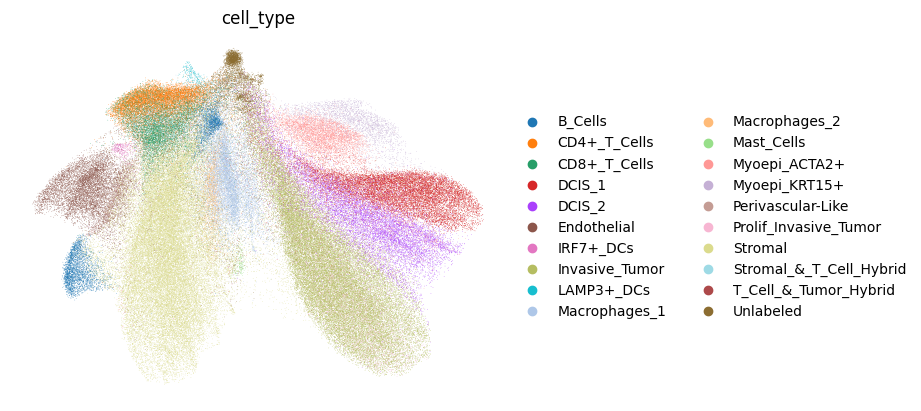

In [ ]:
ad = sdata['table']

# Build neighbors using attention space
sc.pp.neighbors(ad, use_rep="X")

# Compute UMAP
sc.tl.umap(ad)

# Plot
sc.pl.umap(ad, color="cell_type", frameon=False)

In [ ]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

nmi = normalized_mutual_info_score(adatas[0].obs['cell_type'].to_numpy(), adatas[0].obs['steamboat_clusters'].to_numpy())
print("NMI:", nmi)

ari = adjusted_rand_score(adatas[0].obs['cell_type'].to_numpy(), adatas[0].obs['steamboat_clusters'].to_numpy())
print("ARI:", ari)

NMI: 0.6575554012901251
ARI: 0.4905429808329065


In [ ]:
sf.tools.segment(adatas[0], resolution=1)

/content/drive/MyDrive/Thesis/Projects/Steamboat_X/examples/../steamboat/tools.py:457: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  return sc.tl.leiden(adata, obsp=key_added_combined + '_connectivities',


In [ ]:
import spatialdata_plot
axes = plt.subplots(1, 2, figsize=(20, 12))[1].flatten()
sdata.pl.render_images(
    "morphology_focus"
    ).pl.render_shapes(
        "DCIS_1", color="#ffa50060"
        ).pl.render_shapes(
            "DCIS_2", color="#00ff0060"
            ).pl.render_shapes(
                "Invasive", color="#0000ff60"
                ).pl.show(
                    coordinate_systems="global", ax=axes[0], title='Spatial ROIs', colorbar=False
                    )

sq.pl.spatial_scatter(
    adatas[0], color=['steamboat_spatial_domain'], shape=None, ncols=2,
    legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0, hspace=0.0,
    ax=axes[1]
    )

In [ ]:
adatas[0].uns.pop('steamboat_spatial_domain_colors', None)

## Segmentation on ROIs

/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


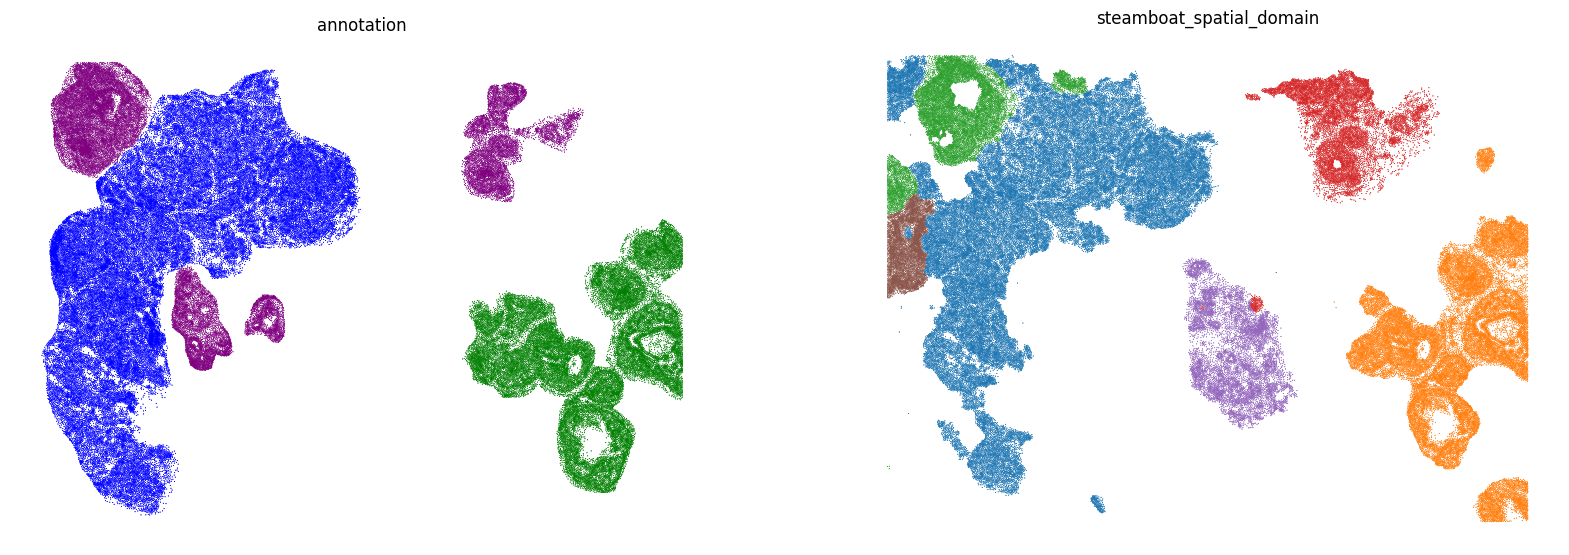

In [ ]:
import spatialdata_plot
from matplotlib.colors import ListedColormap

cmap1 = ListedColormap(['green', 'purple', 'blue'])
axes = plt.subplots(1, 2, figsize=(20, 12))[1].flatten()
mask1 = adatas[0].obs['annotation'].isin(['DCIS_1', 'DCIS_2', 'Invasive'])
sq.pl.spatial_scatter(
    adatas[0][mask1], color=['annotation'],
    palette=cmap1,
    shape=None, ncols=2,
    legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0, hspace=0.0,
    ax=axes[0]
    )
mask2 = adatas[0].obs['steamboat_spatial_domain'].isin(['0', '1', '2', '3', '5', '12'])
sq.pl.spatial_scatter(
    adatas[0][mask2], color=['steamboat_spatial_domain'],
    shape=None, ncols=2,
    legend_loc=None, frameon=False, size=2., lw=0., wspace=0.0, hspace=0.0,
    ax=axes[1]
    )

In [ ]:
adatas[0].obs['cell_type_merged'] = adatas[0].obs['cell_type'].replace(
    {'Invasive_Tumor': 'Tumor', 'Prolif_Invasive_Tumor': 'Tumor'}
)

/tmp/ipython-input-4042335183.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adatas[0].obs['cell_type_merged'] = adatas[0].obs['cell_type'].replace(


### SteamBoat Original

In [ ]:
## SteamBoat Original
from sklearn.metrics import adjusted_rand_score

mask1 = adatas[0].obs['cell_type_merged'].isin(['DCIS_1', 'DCIS_2', 'Tumor'])
mask2 = adatas[0].obs['steamboat_spatial_domain'].isin(['0', '1', '2', '3', '5', '12'])
common_mask = mask1 & mask2


In [ ]:
ari = adjusted_rand_score(adatas[0][mask1].obs['cell_type_merged'].to_numpy(), adatas[0][mask1].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.6627420169781959


In [ ]:
ari = adjusted_rand_score(adatas[0][mask2].obs['cell_type_merged'].to_numpy(), adatas[0][mask2].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.4503335453207296


In [ ]:
ari = adjusted_rand_score(adatas[0][common_mask].obs['cell_type_merged'].to_numpy(), adatas[0][common_mask].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.7948736656782266


In [ ]:
ari = adjusted_rand_score(adatas[0].obs['annotation'].to_numpy(), adatas[0].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.25238091629323456


In [ ]:
ari = adjusted_rand_score(adatas[0][mask2].obs['annotation'].to_numpy(), adatas[0][mask2].obs['steamboat_spatial_domain'].to_numpy())
print("ARI:", ari)

ARI: 0.6820717421591534


In [ ]:
from sklearn.metrics import mutual_info_score

mi = mutual_info_score(adatas[0][mask2].obs['annotation'].to_numpy(), adatas[0][mask2].obs['steamboat_spatial_domain'].to_numpy())
print("Mutual Information:", mi)

Mutual Information: 0.857355728316213


In [ ]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mutual_info_score
from scipy.stats import entropy

def normalized_vi(seg_true, seg_pred):
    seg_true = np.asarray(seg_true).ravel()
    seg_pred = np.asarray(seg_pred).ravel()

    # Encode string (or mixed) labels → integers
    le_true = LabelEncoder()
    le_pred = LabelEncoder()

    seg_true = le_true.fit_transform(seg_true)
    seg_pred = le_pred.fit_transform(seg_pred)

    # Mutual Information
    mi = mutual_info_score(seg_true, seg_pred)

    # Entropies
    H_true = entropy(np.bincount(seg_true) / len(seg_true))
    H_pred = entropy(np.bincount(seg_pred) / len(seg_pred))

    # Normalized VI
    return (H_true + H_pred - 2 * mi) / (H_true + H_pred)


In [ ]:
vi = normalized_vi(adatas[0][mask2].obs['annotation'].to_numpy(), adatas[0][mask2].obs['steamboat_spatial_domain'].to_numpy())
print("VI:", vi)


VI: 0.39495664531841673


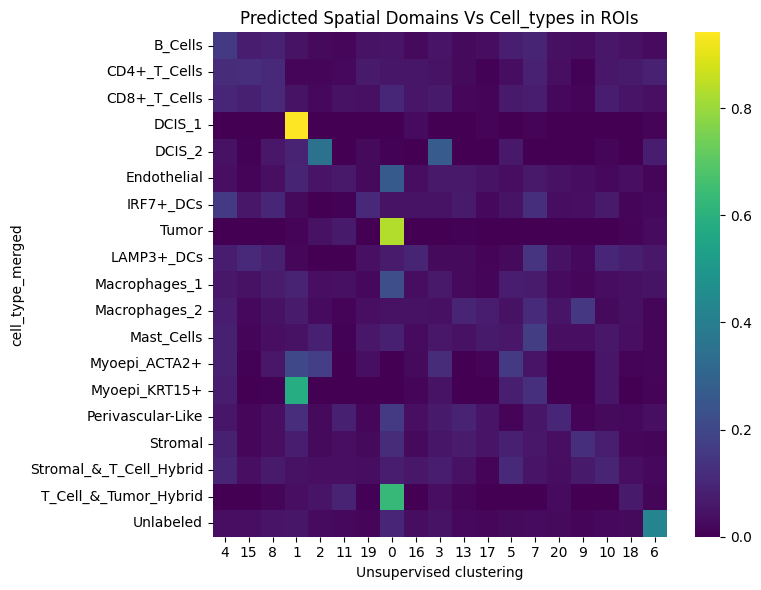

In [ ]:
from scipy.optimize import linear_sum_assignment

label1 = "cell_type_merged"
label2 = "steamboat_spatial_domain"

df = adatas[0].obs[[label1, label2]].dropna()
ct = pd.crosstab(df[label1], df[label2])

if ct.empty:
    raise ValueError("Contingency table is empty.")

# Hungarian algorithm (maximize counts)
cost = -ct.values
row_ind, col_ind = linear_sum_assignment(cost)

# Matched row/column labels
matched_rows = ct.index[row_ind]
matched_cols = ct.columns[col_ind]

# Unmatched row/column labels
unmatched_rows = ct.index.difference(matched_rows)
unmatched_cols = ct.columns.difference(matched_cols)

# Final order: matched first, then unmatched
row_order = matched_rows.tolist() + unmatched_rows.tolist()
#row_order = matched_rows.tolist()
#col_order = matched_cols.tolist() + unmatched_cols.tolist()
col_order = matched_cols.tolist()

# Reorder full contingency table
ct_reordered = ct.loc[row_order, col_order]

# Row-normalize
ct_norm = ct_reordered.div(ct_reordered.sum(axis=1), axis=0)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(ct_norm, cmap="viridis")
plt.xlabel("Unsupervised clustering")
plt.ylabel(label1)
plt.title("Predicted Spatial Domains Vs Cell_types in ROIs")
plt.tight_layout()
plt.show()
